<a href="https://colab.research.google.com/github/likith1525/ExcelR-data-science-assignments/blob/main/Codes/13XGBM_LGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv("/content/diabetes (1).csv")

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.shape

(768, 9)

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


# EDA

In [ ]:
# replace 0 with nan for further computing
cols_with_zeros = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for col in cols_with_zeros:
  df[col].replace(0,np.nan,inplace=True)

/tmp/ipykernel_12703/2983452161.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace(0,np.nan,inplace=True)


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report
import xgboost as xgb
import lightgbm as lgb

In [ ]:
sns.set_theme(style="whitegrid")

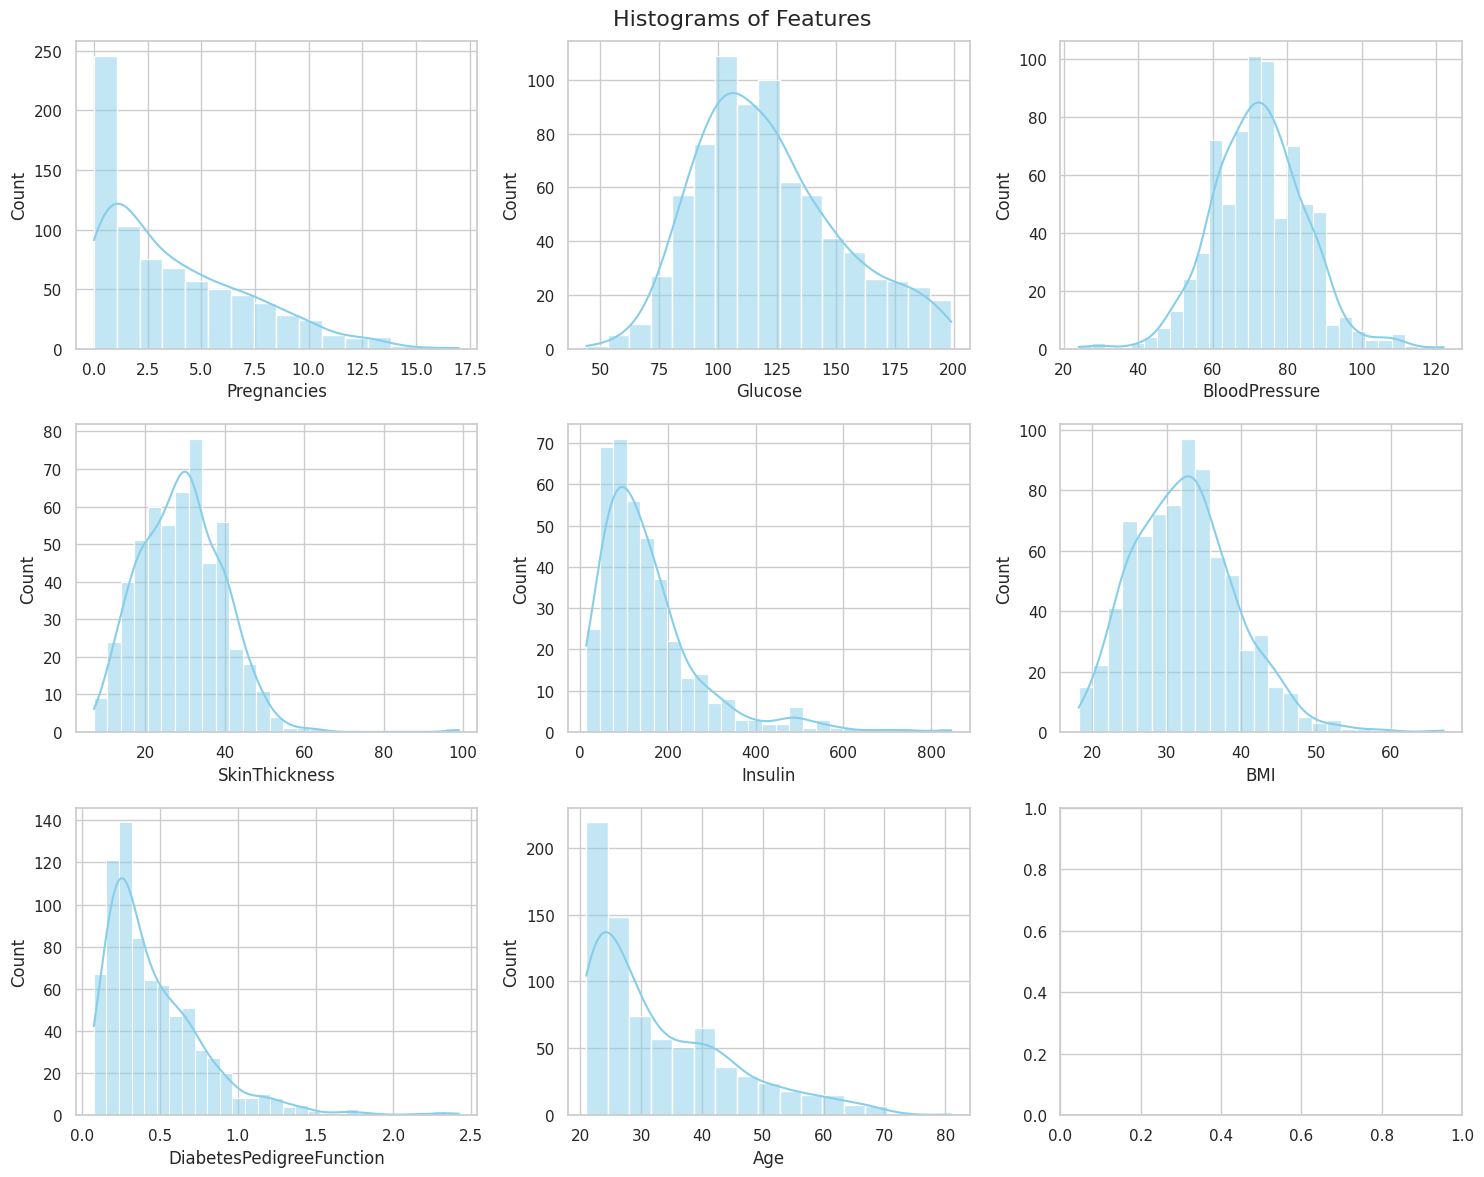

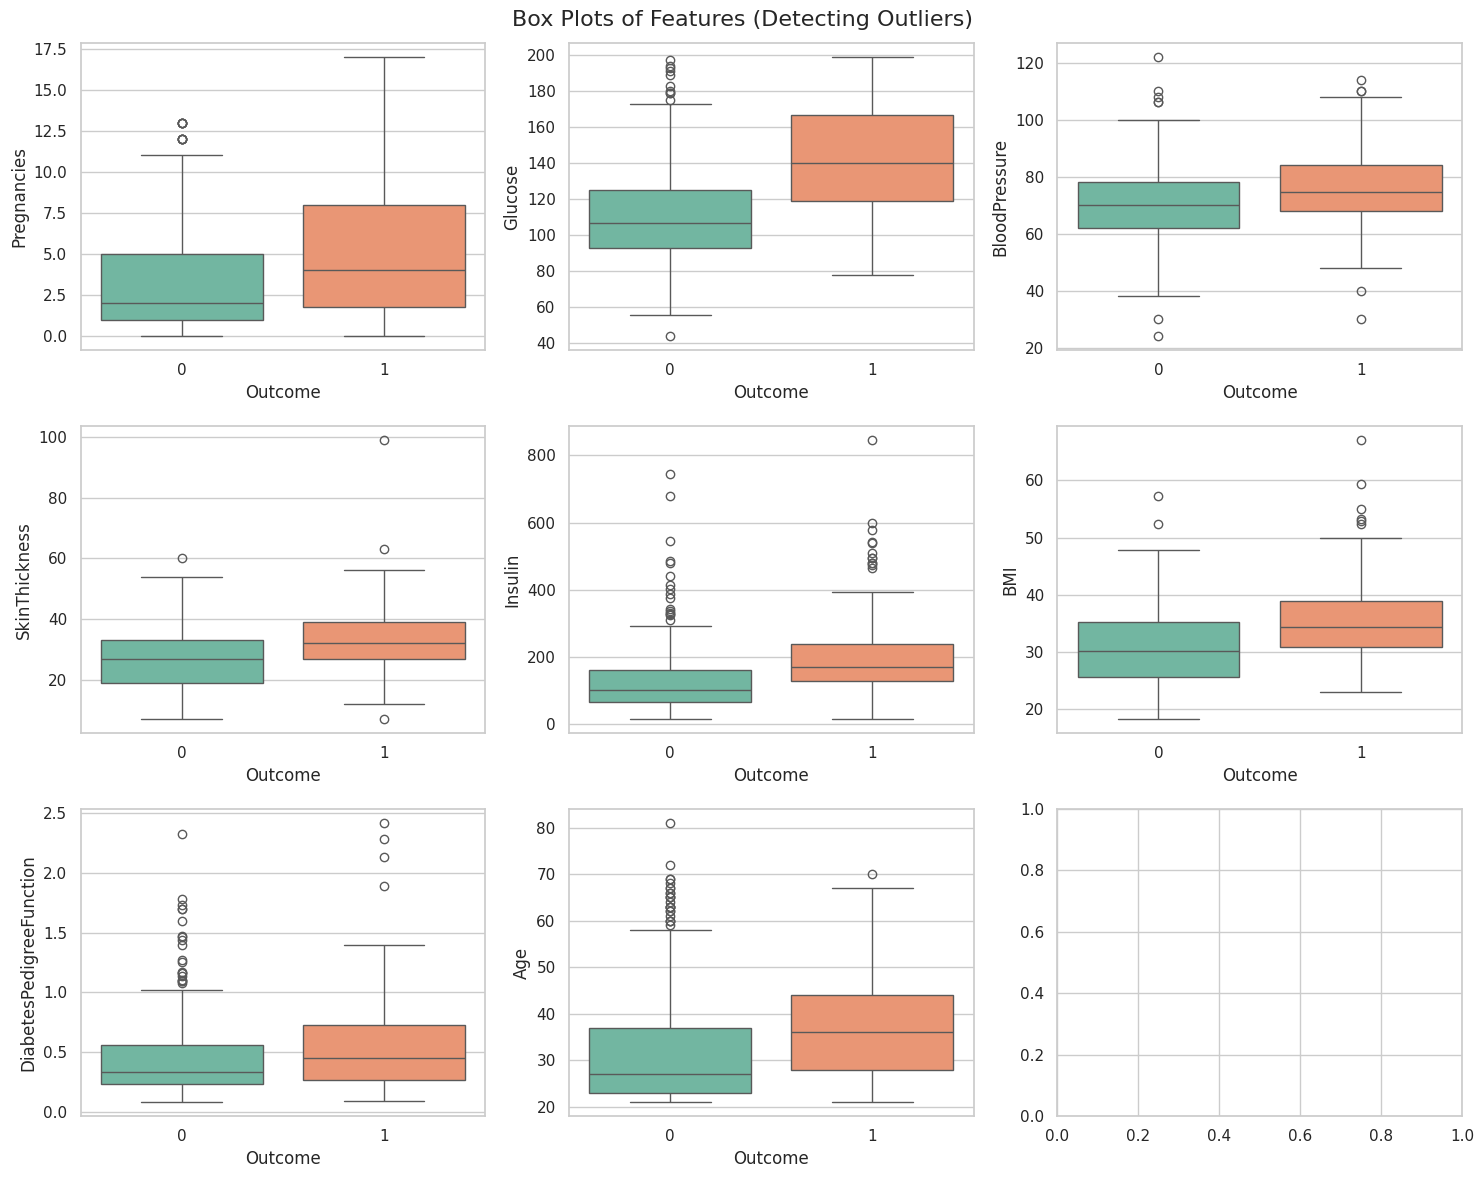

In [ ]:
# Explore data distributions using histograms and box plots
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle('Histograms of Features', fontsize=16)
for i, col in enumerate(df.columns[:-1]):
    sns.histplot(df[col], kde=True, ax=axes[i//3, i%3], color='skyblue')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle('Box Plots of Features (Detecting Outliers)', fontsize=16)
for i, col in enumerate(df.columns[:-1]):
    sns.boxplot(y=df[col], x=df['Outcome'], ax=axes[i//3, i%3], palette='Set2')
plt.tight_layout()
plt.show()

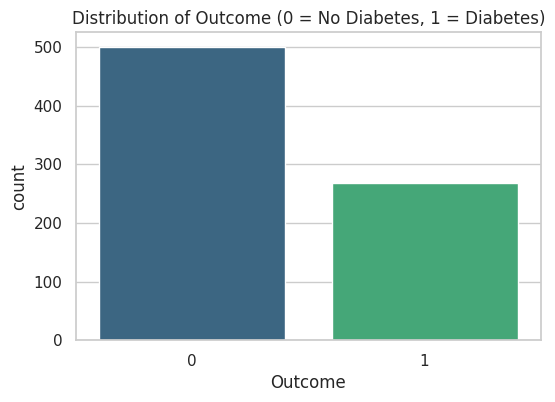

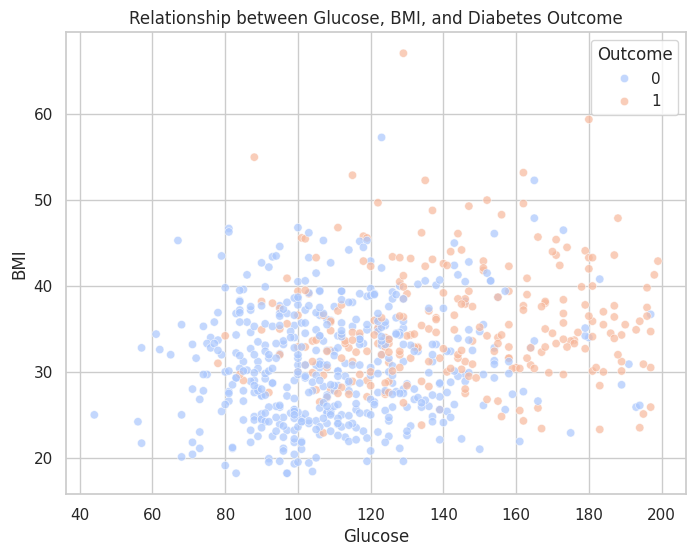

In [ ]:
# Visualize relationships between features and outcome (Scatter & Bar plots)

# Bar plot for class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='viridis')
plt.title('Distribution of Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.show()

# Scatter plot: Glucose vs BMI colored by Outcome
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df, palette='coolwarm', alpha=0.7)
plt.title('Relationship between Glucose, BMI, and Diabetes Outcome')
plt.show()

#Data Preprocessing

In [ ]:
# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 1. Impute missing values (using median because of outliers seen in boxplots)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 2. Encoding categorical variables
# (Not applicable here as all features are numeric. The target 'Outcome' is already 0 and 1).

# 3. Additional Preprocessing: Feature Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)

print("Data preprocessing complete. Features imputed and scaled.")
display(X_scaled.head())

Data preprocessing complete. Features imputed and scaled.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.866045,-0.031990,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.205066,-0.528319,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.016662,-0.693761,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.073567,-0.528319,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.504422,-2.679076,0.670643,0.316566,1.549303,5.484909,-0.020496


In [ ]:
# 1. Split the preprocessed dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 2 & 5. Define models and hyperparameter grids for tuning
# XGBoost Grid
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# LightGBM Grid
lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
lgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, -1],
    'learning_rate': [0.01, 0.1, 0.2]
}

# 3, 4 & 5. Train and tune models using GridSearchCV
print("Training and tuning XGBoost...")
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

print("Training and tuning LightGBM...")
lgb_grid = GridSearchCV(lgb_model, lgb_params, cv=5, scoring='accuracy', n_jobs=-1)
lgb_grid.fit(X_train, y_train)
best_lgb = lgb_grid.best_estimator_

print("\nBest XGBoost Parameters:", xgb_grid.best_params_)
print("Best LightGBM Parameters:", lgb_grid.best_params_)

Training and tuning XGBoost...
Training and tuning LightGBM...

Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best LightGBM Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}


,Accuracy,Precision,Recall,F1-Score
XGBoost,0.746753,0.666667,0.555556,0.606061
LightGBM,0.772727,0.686275,0.648148,0.666667


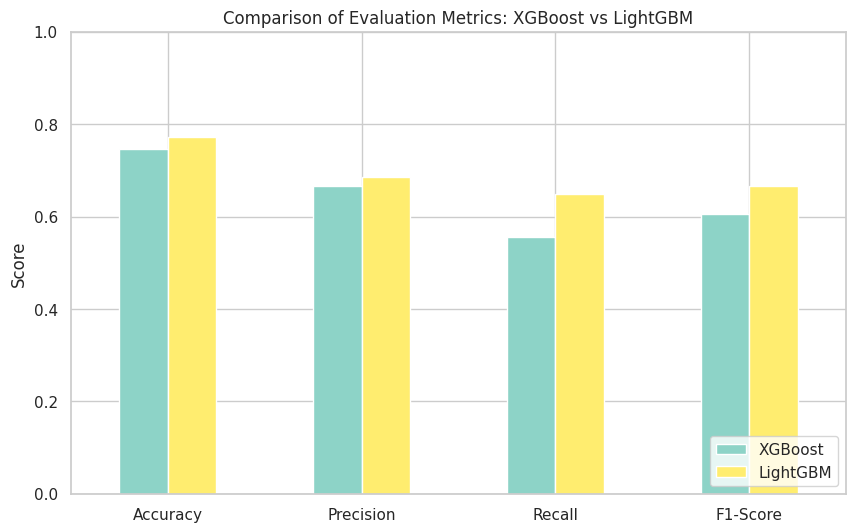

In [ ]:
# Function to get metrics
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

# 1. Compare performance metrics
xgb_metrics = evaluate_model(best_xgb, X_test, y_test)
lgb_metrics = evaluate_model(best_lgb, X_test, y_test)

metrics_df = pd.DataFrame([xgb_metrics, lgb_metrics], index=['XGBoost', 'LightGBM'])
display(metrics_df)

# 2. Visualize the results
metrics_df.T.plot(kind='bar', figsize=(10, 6), colormap='Set3')
plt.title('Comparison of Evaluation Metrics: XGBoost vs LightGBM')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1.0)
plt.show()

## summary report
###Comparative Analysis Report
  *   **`performance:`** Both XGboost and Lightgbm perform relatively similar on the dataset , also achieve an accuracy between 70% and 80%.
  *   **Strengths & Weakness:**

      * `XGboost:`Excellent at handlng the complex,non-linear relationships.it tends to be highly robust to overfitiing when hyperparameters like max_depth and learning_rate are properly tuned.
      It can be computationaly heavier than Lightgbm on massive datasets.
      
      * `Lightgbm:`Uses a leaf -wise tre growth algorithm ,making it generalyy faster and more memory eficient tha XGBoost .
      on smaller datasets like ,the speed difference is negligible ,but it can sometimes overfit if max_deth isnt controllable.